# 03 – Feature Extraction Pipeline (MediaPipe + Fretboard)

**Szerző:** Magda Ferenc (U5O0BB)  
**Projekt:** Gitár akkord felismerő – gépi látással  
**Notebook célja:** A tervezett architektúra implementálása:

```
Nyers kép → OpenCV fretboard detect. → MediaPipe kéz keypoints → Feature vektor → ML klasszifikátor
```

**Feature vektor összetétele (111 dim összesen):**

| Csoport | Tartalom | Méret |
|---|---|---|
| A | Raw MediaPipe landmarks (21 pt × x,y,z) | 63 |
| B | Csukló-centrált, skálázott landmarks (21 pt × x,y) | 42 |
| C | Fretboard bounding box (x, y, w, h – normalizált) | 4 |
| D | Detekciós zászlók (hand_detected, fb_detected) | 2 |

**CUDA-stratégia:** MediaPipe + OpenCV = CPU-bound. PyTorch CUDA elérhető  
marad a normalizáláshoz és a downstream ML/CNN notebookokhoz.

---

## Tartalomjegyzék
1. Könyvtárak és konfiguráció  
2. CUDA diagnosztika  
3. MediaPipe model előkészítés  
4. Manifest betöltése  
5. Fretboard detektálás (OpenCV)  
6. Kéz landmark detektálás (MediaPipe)  
7. Feature vektor összeállítás  
8. Batch feature extraction  
9. Feature validáció és statisztikák  
10. Normalizálás (train-fit, val/test transform)  
11. Mentés  
12. Sanity check vizualizáció

## 1. Könyvtárak és konfiguráció

In [10]:
import os
import sys
import time
import warnings
import urllib.request
from pathlib import Path
from typing import Optional

# OpenCV import: try import, fallback to automatic pip install if missing
CV2_AVAILABLE = False
try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    import subprocess, sys
    print("⚠️  OpenCV (cv2) nem található. Megpróbálom telepíteni: opencv-python")
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'opencv-python'])
        import cv2
        CV2_AVAILABLE = True
        print("✅  OpenCV telepítve és importálva.")
    except Exception as e:
        print(f"❌  OpenCV telepítése sikertelen: {e}")
        CV2_AVAILABLE = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

import torch

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

# ── Elérési utak ──────────────────────────────────────────────────────────────
NOTEBOOK_DIR   = Path.cwd()
PROJECT_ROOT   = NOTEBOOK_DIR.parent
DATA_ROOT      = PROJECT_ROOT / "data"
MANIFEST_PATH  = DATA_ROOT / "split_manifest.csv"
FEATURES_DIR   = DATA_ROOT / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# A features.npz és scaler.pkl ide kerül
FEATURES_PATH      = FEATURES_DIR / "features.npz"
SCALER_PATH        = FEATURES_DIR / "scaler.pkl"
FEATURE_NAMES_PATH = FEATURES_DIR / "feature_names.txt"

# MediaPipe model helye – első futáskor automatikusan letöltődik
MODEL_DIR  = PROJECT_ROOT / "models"
MODEL_PATH = MODEL_DIR / "hand_landmarker.task"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = PROJECT_ROOT / "output" / "03_feature_pipeline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Konstansok ────────────────────────────────────────────────────────────────
N_LANDMARKS = 21
# Feature csoporthatárok
GROUP_A_SIZE = N_LANDMARKS * 3          # 63: raw x,y,z
GROUP_B_SIZE = N_LANDMARKS * 2          # 42: wrist-centered x,y
GROUP_C_SIZE = 4                        # fb bbox
GROUP_D_SIZE = 2                        # flags
FEATURE_SIZE = GROUP_A_SIZE + GROUP_B_SIZE + GROUP_C_SIZE + GROUP_D_SIZE  # 111

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Elérési út ellenőrzés
for p in [DATA_ROOT, MANIFEST_PATH]:
    status = "OK" if p.exists() else "❌ NEM TALÁLHATÓ"
    print(f"{status}  {p}")
print(f"Features dir: {FEATURES_DIR}")
print(f"Model path:   {MODEL_PATH}")
print(f"Feature size: {FEATURE_SIZE} dim")

OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data
OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/split_manifest.csv
Features dir: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/features
Model path:   /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/models/hand_landmarker.task
Feature size: 111 dim


## 2. CUDA diagnosztika

In [11]:
print("=" * 65)
print("CUDA / GPU DIAGNOSZTIKA")
print("=" * 65)

# PyTorch CUDA (downstream ML/CNN notebookokhoz)
print("\nPyTorch verzió :", torch.__version__)
CUDA_AVAILABLE = torch.cuda.is_available()
print("CUDA elérhető  :", CUDA_AVAILABLE)
if CUDA_AVAILABLE:
    GPU_NAME = torch.cuda.get_device_name(0)
    VRAM_GB  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print("GPU            :", GPU_NAME)
    print(f"VRAM           : {VRAM_GB:.1f} GB")
    DEVICE = torch.device("cuda")
else:
    print("⚠️  CUDA nem elérhető – PyTorch CPU módban fut.")
    DEVICE = torch.device("cpu")

# OpenCV CUDA (képfeldolgozáshoz)
if CV2_AVAILABLE:
    try:
        print("\nOpenCV verzió  :", cv2.__version__)
        CV2_CUDA = hasattr(cv2, 'cuda') and cv2.cuda.getCudaEnabledDeviceCount() > 0
        print("OpenCV CUDA    :", 'elérhető' if CV2_CUDA else 'nem elérhető (conda-forge build – normális)')
        if CV2_CUDA:
            print('  GPU count    :', cv2.cuda.getCudaEnabledDeviceCount())
    except Exception as e:
        print('⚠️  OpenCV elérhető, de hiba történt az ellenőrzésnél:', e)
        CV2_CUDA = False
else:
    print("\nOpenCV: NEM ELÉRHETŐ – egyes preprocessing lépések kihagyhatók.")

print("\nMediaPipe futtatás: CPU")
print("  Megjegyzés: MediaPipe tasks API-n az ujjdetektálás CPU-on fut.")
print("  A GPU (CUDA) a preprocessing után az ML és CNN notebookokhoz áll rendelkezésre.")

print("=" * 65)
print("\nAktív PyTorch eszköz:", DEVICE)
print("=" * 65)


CUDA / GPU DIAGNOSZTIKA

PyTorch verzió : 2.6.0+cu124
CUDA elérhető  : True
GPU            : NVIDIA T500
VRAM           : 3.8 GB

OpenCV verzió  : 4.13.0
OpenCV CUDA    : nem elérhető (conda-forge build – normális)

MediaPipe futtatás: CPU
  Megjegyzés: MediaPipe tasks API-n az ujjdetektálás CPU-on fut.
  A GPU (CUDA) a preprocessing után az ML és CNN notebookokhoz áll rendelkezésre.

Aktív PyTorch eszköz: cuda


## 3. MediaPipe Hand Landmarker model előkészítés

In [12]:
# MediaPipe 0.10.x Tasks API – a modell egy .task fájl, automatikusan letöltjük
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
)

def download_model(url: str, dest: Path, force: bool = False) -> bool:
    """Letölti a MediaPipe modell fájlt, ha még nincs meg."""
    if dest.exists() and dest.stat().st_size > 10_000 and not force:
        print(f"✅  Model már megvan: {dest}  ({dest.stat().st_size // 1024} KB)")
        return True
    print(f"Letöltés: {url}")
    print(f"  → {dest}")
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as response:
            data = response.read()
        dest.write_bytes(data)
        print(f"✅  Letöltve: {len(data) // 1024} KB")
        return True
    except Exception as e:
        print(f"❌  Letöltési hiba: {e}")
        print(f"   Kézzel töltsd le innen: {url}")
        print(f"   Mentsd ide: {dest}")
        return False

model_ok = download_model(MODEL_URL, MODEL_PATH)

# Próbáljuk importálni a mediapipe-t; ha nincs, adjunk informatív üzenetet és folytassuk HAND_LANDMARKER=None mellett
mediapipe_available = False
try:
    import mediapipe as mp
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision as mp_vision
    from mediapipe.tasks.python.core.base_options import BaseOptions
    mediapipe_available = True
except Exception as e:
    print("⚠️  mediapipe nem elérhető:", e)
    print("Telepítési javaslatok:")
    print("  - Conda (ajánlott): conda install -c conda-forge mediapipe")
    print("  - Pip: pip install mediapipe")
    print("Ha speciális platformod van (pl. Raspberry Pi), kövesd a mediapipe telepítési útmutatóját.")

if model_ok and mediapipe_available:
    _base_opts = BaseOptions(
        model_asset_path=str(MODEL_PATH),
        delegate=BaseOptions.Delegate.CPU,  # CPU-on fut stabilan
    )
    _hand_opts = mp_vision.HandLandmarkerOptions(
        base_options=_base_opts,
        running_mode=mp_vision.RunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=0.3,
        min_hand_presence_confidence=0.3,
        min_tracking_confidence=0.3,
    )
    HAND_LANDMARKER = mp_vision.HandLandmarker.create_from_options(_hand_opts)
    print("✅  HandLandmarker készen áll.")
else:
    HAND_LANDMARKER = None
    if not model_ok:
        print("⚠️  MediaPipe modell nem elérhető – a letöltés sikertelen volt.")
    if not mediapipe_available:
        print("⚠️  HandLandmarker nem inicializálható, mert a 'mediapipe' csomag hiányzik. A kéz-detekciós feature-ök nullák lesznek.")


✅  Model már megvan: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/models/hand_landmarker.task  (7635 KB)
✅  HandLandmarker készen áll.


I0000 00:00:1778790808.497889  586624 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778790808.502137  586638 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778790808.517478  586627 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778790808.534631  586632 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 4. Manifest betöltése

In [13]:
manifest = pd.read_csv(MANIFEST_PATH)
CLASSES    = sorted(manifest["class"].unique())
CLASS2IDX  = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS  = {i: c for c, i in CLASS2IDX.items()}
NUM_CLASSES = len(CLASSES)
manifest["label"] = manifest["class"].map(CLASS2IDX)

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df   = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df  = manifest[manifest["split"] == "test"].reset_index(drop=True)

print(f"Osztályok ({NUM_CLASSES}): {CLASSES}")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print()
print("Osztály-eloszlás:")
print(manifest.groupby(["split", "class"]).size().unstack(fill_value=0).to_string())

Osztályok (8): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No hand']
Train: 207 | Val: 45 | Test: 45

Osztály-eloszlás:
class   A   B   C   D   E   F   G  No hand
split                                     
test    5   9   7   7   4   7   4        2
train  23  39  33  31  22  34  15       10
val     5   8   7   6   5   8   3        3


## 5. Fretboard detektálás (OpenCV)

**Stratégia:**
1. **Hough-alapú (elsődleges):** Canny éldetek → HoughLinesP → vízszintes vonalak keresése  
   (a frets közel vízszintes csíkok a fogólapon)
2. **Kontúr-alapú (fallback):** sötét téglalap alakú régió keresése morfológiai zárás után
3. **Végső fallback:** `None` visszaadása (a feature vektorban nullák kerülnek oda)

A visszaadott koordináták az eredeti képmérethez normalizálva (0–1 tartomány).

In [14]:
def detect_fretboard(img_bgr: np.ndarray) -> Optional[dict]:
    """
    Detektálja a gitár fogólapját (fretboard) egy BGR képen.

    Visszaad: dict {'x', 'y', 'bw', 'bh', 'cx', 'cy', 'method'}
    ahol minden érték 0–1 közé normalizált,
    vagy None ha sikertelen.
    """
    # If OpenCV is not available, skip fretboard detection (return None).
    if not CV2_AVAILABLE:
        return None

    h, w = img_bgr.shape[:2]
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # ── Stratégia 1: Hough-alapú fret detektálás ─────────────────────────────
    edges = cv2.Canny(blurred, 30, 100)
    lines = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi / 180,
        threshold=40,
        minLineLength=int(w * 0.25),
        maxLineGap=20,
    )

    if lines is not None:
        horiz = []
        for ln in lines:
            x1, y1, x2, y2 = ln[0]
            angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            # Vízszintes: szög < 25° vagy > 155°
            if angle < 25 or angle > 155:
                horiz.append(ln[0])

        if len(horiz) >= 2:
            all_x = [l[0] for l in horiz] + [l[2] for l in horiz]
            all_y = [l[1] for l in horiz] + [l[3] for l in horiz]
            x1b, y1b = min(all_x), min(all_y)
            x2b, y2b = max(all_x), max(all_y)
            bw_px, bh_px = x2b - x1b, y2b - y1b

            # Elfogadási feltétel: kellő szélességű és nem degenerált
            if bw_px > w * 0.15 and bh_px > 4:
                return dict(
                    x=x1b / w, y=y1b / h,
                    bw=bw_px / w, bh=bh_px / h,
                    cx=(x1b + x2b) / (2 * w),
                    cy=(y1b + y2b) / (2 * h),
                    method="hough",
                )

    # ── Stratégia 2: Sötét téglalap kontúr ───────────────────────────────────
    _, dark = cv2.threshold(blurred, 75, 255, cv2.THRESH_BINARY_INV)
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    dark    = cv2.morphologyEx(dark, cv2.MORPH_CLOSE, kernel)
    cnts, _ = cv2.findContours(dark, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not cnts:
        return None

    img_area = h * w
    best_cnt, best_score = None, 0.0
    for cnt in cnts:
        area = cv2.contourArea(cnt)
        if area < img_area * 0.04:       # minimum 4% képterület
            continue
        xr, yr, wr, hr = cv2.boundingRect(cnt)
        rect_fill = area / max(wr * hr, 1)   # mennyire tölti ki a befoglalót
        score = rect_fill * (area / img_area)
        if score > best_score:
            best_score = score
            best_cnt = (xr, yr, wr, hr)

    if best_cnt is None:
        return None

    xr, yr, wr, hr = best_cnt
    return dict(
        x=xr / w, y=yr / h,
        bw=wr / w, bh=hr / h,
        cx=(xr + wr / 2) / w,
        cy=(yr + hr / 2) / h,
        method="contour",
    )

print("✅  detect_fretboard() definiálva.")
print("   Kimenet: {'x','y','bw','bh','cx','cy','method'} vagy None")

✅  detect_fretboard() definiálva.
   Kimenet: {'x','y','bw','bh','cx','cy','method'} vagy None


## 6. Kéz landmark detektálás (MediaPipe)

A MediaPipe HandLandmarker **21 pontot** ad vissza, mindegyikhez `x`, `y`, `z`  
koordináta (0–1 normalizálva az eredeti képméretre).

**Landmark indexek** (fontos referenciapontok):  
- `0` = csukló (wrist) → csukló-centrálás alapja  
- `9` = középső ujj MCP → skálázás alapja  
- `4,8,12,16,20` = hüvelyk/mutató/közép/gyűrűs/kisujj hegye

In [15]:
def detect_hand_landmarks(
    img_path: str,
    landmarker=None,
) -> Optional[list]:
    """
    Detektálja a kéz 21 landmark pontját egy képen.

    Returns:
        list of (x, y, z) tuples (21 elem, normalizált 0–1)
        vagy None ha nincs kéz detektálva / hiba esetén
    """
    if landmarker is None:
        return None

    try:
        # PIL → numpy RGB (MediaPipe mp.Image-hez szükséges)
        pil_img = Image.open(img_path).convert("RGB")
        np_img  = np.array(pil_img, dtype=np.uint8)

        try:
            import mediapipe as mp
            mp_img  = mp.Image(image_format=mp.ImageFormat.SRGB, data=np_img)
            result = landmarker.detect(mp_img)
        except Exception:
            return None

        if not result.hand_landmarks or len(result.hand_landmarks) == 0:
            return None

        # Első (és egyetlen) kéz landmark-jai
        hand = result.hand_landmarks[0]
        return [(lm.x, lm.y, lm.z) for lm in hand]

    except Exception:
        return None  # Sérült kép vagy egyéb hiba esetén

print("✅  detect_hand_landmarks() definiálva.")
print("   HandLandmarker:", "elérhető" if HAND_LANDMARKER is not None else "NEM ELÉRHETŐ")

✅  detect_hand_landmarks() definiálva.
   HandLandmarker: elérhető


## 7. Feature vektor összeállítás

In [16]:
# Feature nevek – referencia a downstream ML notebookokhoz
FEATURE_NAMES = []
# Csoport A: raw landmarks (63)
for i in range(N_LANDMARKS):
    FEATURE_NAMES += [f"lm{i:02d}_x", f"lm{i:02d}_y", f"lm{i:02d}_z"]
# Csoport B: wrist-centered (42)
for i in range(N_LANDMARKS):
    FEATURE_NAMES += [f"wc{i:02d}_x", f"wc{i:02d}_y"]
# Csoport C: fretboard bbox (4)
FEATURE_NAMES += ["fb_x", "fb_y", "fb_w", "fb_h"]
# Csoport D: flags (2)
FEATURE_NAMES += ["hand_detected", "fb_detected"]

assert len(FEATURE_NAMES) == FEATURE_SIZE, \
    f"Feature névlista hossz hiba: {len(FEATURE_NAMES)} != {FEATURE_SIZE}"

print(f"Feature nevek: {len(FEATURE_NAMES)} db")
print(f"  Csoport A (raw lm)     : {FEATURE_NAMES[0]}  …  {FEATURE_NAMES[GROUP_A_SIZE-1]}")
print(f"  Csoport B (wrist-cent) : {FEATURE_NAMES[GROUP_A_SIZE]}  …  "
      f"{FEATURE_NAMES[GROUP_A_SIZE+GROUP_B_SIZE-1]}")
print(f"  Csoport C (fretboard)  : {FEATURE_NAMES[GROUP_A_SIZE+GROUP_B_SIZE]}  …  "
      f"{FEATURE_NAMES[GROUP_A_SIZE+GROUP_B_SIZE+GROUP_C_SIZE-1]}")
print(f"  Csoport D (flags)      : {FEATURE_NAMES[-2]}, {FEATURE_NAMES[-1]}")

Feature nevek: 111 db
  Csoport A (raw lm)     : lm00_x  …  lm20_z
  Csoport B (wrist-cent) : wc00_x  …  wc20_y
  Csoport C (fretboard)  : fb_x  …  fb_h
  Csoport D (flags)      : hand_detected, fb_detected


In [17]:
def assemble_feature_vector(
    landmarks: Optional[list],
    fb: Optional[dict],
) -> np.ndarray:
    """
    Összeállítja a 111-dimenziós feature vektort.

    Parameters
    ----------
    landmarks : list of (x,y,z) × 21, vagy None
    fb        : detect_fretboard() visszatérési értéke, vagy None

    Returns
    -------
    np.ndarray – shape (111,), dtype float32
    """
    feats = []

    # ── Csoport A: Raw landmarks (63) ────────────────────────────────────────
    if landmarks is not None:
        hand_detected = 1.0
        for x, y, z in landmarks:
            feats.extend([float(x), float(y), float(z)])
    else:
        hand_detected = 0.0
        feats.extend([0.0] * GROUP_A_SIZE)

    # ── Csoport B: Wrist-centered, scale-normalized (42) ─────────────────────
    if landmarks is not None:
        wrist_x, wrist_y = landmarks[0][0], landmarks[0][1]
        # Skálázás alap: csukló → középső ujj MCP távolság (landmark 9)
        mid_x, mid_y = landmarks[9][0], landmarks[9][1]
        hand_scale = max(
            np.hypot(mid_x - wrist_x, mid_y - wrist_y),
            1e-6,
        )
        for x, y, _ in landmarks:
            feats.extend([
                (x - wrist_x) / hand_scale,
                (y - wrist_y) / hand_scale,
            ])
    else:
        feats.extend([0.0] * GROUP_B_SIZE)

    # ── Csoport C: Fretboard bbox (4) ────────────────────────────────────────
    if fb is not None:
        fb_detected = 1.0
        feats.extend([
            float(fb["x"]),
            float(fb["y"]),
            float(fb["bw"]),
            float(fb["bh"]),
        ])
    else:
        fb_detected = 0.0
        feats.extend([0.0] * GROUP_C_SIZE)

    # ── Csoport D: Flags (2) ─────────────────────────────────────────────────
    feats.extend([hand_detected, fb_detected])

    vec = np.array(feats, dtype=np.float32)
    assert vec.shape == (FEATURE_SIZE,), f"Feature méret hiba: {vec.shape}"
    return vec


def extract_features_from_row(row: pd.Series) -> np.ndarray:
    """Egy manifest sor → feature vektor."""
    img_path = row["path"]

    # Ellenőrizzük, hogy a fájl olvasható-e (PIL használatával) – MediaPipe használ PIL-t
    try:
        Image.open(img_path)
    except Exception:
        # Sérült / nem olvasható kép – nullvektor
        return np.zeros(FEATURE_SIZE, dtype=np.float32)

    # Fretboard detekció csak ha OpenCV elérhető
    fb = None
    if CV2_AVAILABLE:
        img_bgr = cv2.imread(img_path)
        if img_bgr is not None:
            fb = detect_fretboard(img_bgr)

    # Hand landmarks (MediaPipe – PIL->mp.Image belső használat)
    landmarks = detect_hand_landmarks(img_path, HAND_LANDMARKER)

    return assemble_feature_vector(landmarks, fb)


print("✅  assemble_feature_vector() és extract_features_from_row() definiálva.")

✅  assemble_feature_vector() és extract_features_from_row() definiálva.


## 8. Batch feature extraction

In [18]:
def extract_split(df: pd.DataFrame, split_name: str) -> tuple:
    """
    Kinyeri a feature vektorokat egy teljes split minden képéhez.
    Returns: (X, y, det_stats)
    """
    X      = np.zeros((len(df), FEATURE_SIZE), dtype=np.float32)
    y      = df["label"].values.astype(np.int64)
    n_hand = 0
    n_fb   = 0

    t0 = time.time()
    for i, (_, row) in enumerate(tqdm(df.iterrows(),
                                       total=len(df),
                                       desc=f"  {split_name}")):
        vec  = extract_features_from_row(row)
        X[i] = vec
        n_hand += int(vec[-2])   # hand_detected flag
        n_fb   += int(vec[-1])   # fb_detected flag

    elapsed = time.time() - t0
    det_stats = {
        "split":          split_name,
        "n_images":       len(df),
        "hand_detected":  n_hand,
        "hand_rate_%":    round(100 * n_hand / len(df), 1),
        "fb_detected":    n_fb,
        "fb_rate_%":      round(100 * n_fb / len(df), 1),
        "elapsed_s":      round(elapsed, 1),
    }
    return X, y, det_stats


print("Feature extraction indítása...")
print(f"Összesen: {len(manifest)} kép | Feature méret: {FEATURE_SIZE} dim")
print("-" * 55)

all_stats = []

X_train, y_train, s_train = extract_split(train_df, "train")
all_stats.append(s_train)
print(f"  Kéz:      {s_train['hand_detected']}/{s_train['n_images']} ({s_train['hand_rate_%']}%)")
print(f"  Fretboard:{s_train['fb_detected']}/{s_train['n_images']} ({s_train['fb_rate_%']}%)")

X_val, y_val, s_val = extract_split(val_df, "val")
all_stats.append(s_val)
print(f"  Kéz:      {s_val['hand_detected']}/{s_val['n_images']} ({s_val['hand_rate_%']}%)")

X_test, y_test, s_test = extract_split(test_df, "test")
all_stats.append(s_test)
print(f"  Kéz:      {s_test['hand_detected']}/{s_test['n_images']} ({s_test['hand_rate_%']}%)")

print()
print("Detekciós összefoglaló:")
stats_df = pd.DataFrame(all_stats)
print(stats_df.to_string(index=False))

Feature extraction indítása...
Összesen: 297 kép | Feature méret: 111 dim
-------------------------------------------------------


  train: 100%|██████████| 207/207 [01:26<00:00,  2.38it/s]


  Kéz:      195/207 (94.2%)
  Fretboard:207/207 (100.0%)


  val: 100%|██████████| 45/45 [00:19<00:00,  2.34it/s]


  Kéz:      41/45 (91.1%)


  test: 100%|██████████| 45/45 [00:19<00:00,  2.37it/s]

  Kéz:      42/45 (93.3%)

Detekciós összefoglaló:
split  n_images  hand_detected  hand_rate_%  fb_detected  fb_rate_%  elapsed_s
train       207            195         94.2          207      100.0       86.9
  val        45             41         91.1           45      100.0       19.2
 test        45             42         93.3           45      100.0       19.0


## 9. Feature validáció és statisztikák

In [19]:
# ── 9a. NaN / Inf ellenőrzés ──────────────────────────────────────────────────
issues = []
for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    nan_c = np.isnan(X).sum()
    inf_c = np.isinf(X).sum()
    if nan_c or inf_c:
        issues.append(f"❌  {name}: {nan_c} NaN, {inf_c} Inf!")
    else:
        print(f"✅  {name}: nincs NaN/Inf  (shape {X.shape})")
if issues:
    for i in issues:
        print(i)

# ── 9b. Detekciós ráta osztályonként ──────────────────────────────────────────
print()
print("Detekciós ráta osztályonként (train split):")
hand_flag_idx = FEATURE_NAMES.index("hand_detected")
fb_flag_idx   = FEATURE_NAMES.index("fb_detected")

rows = []
for cls in CLASSES:
    mask  = y_train == CLASS2IDX[cls]
    n     = mask.sum()
    h_rt  = X_train[mask, hand_flag_idx].mean() * 100
    f_rt  = X_train[mask, fb_flag_idx].mean() * 100
    rows.append({"Osztály": cls, "N": n,
                 "Kéz det.%": round(h_rt, 1),
                 "Fretboard det.%": round(f_rt, 1)})
det_per_class = pd.DataFrame(rows)
print(det_per_class.to_string(index=False))

# ── 9c. Wrist-centrált feature statisztikák ───────────────────────────────────
print()
wc_start = GROUP_A_SIZE
wc_end   = GROUP_A_SIZE + GROUP_B_SIZE
wc_train = X_train[:, wc_start:wc_end]

print("Csukló-centrált feature-ök (Csoport B) – train split:")
print(f"  Mean: {wc_train.mean():.4f}")
print(f"  Std:  {wc_train.std():.4f}")
print(f"  Min:  {wc_train.min():.4f}")
print(f"  Max:  {wc_train.max():.4f}")

✅  train: nincs NaN/Inf  (shape (207, 111))
✅  val: nincs NaN/Inf  (shape (45, 111))
✅  test: nincs NaN/Inf  (shape (45, 111))

Detekciós ráta osztályonként (train split):
Osztály  N  Kéz det.%  Fretboard det.%
      A 23 100.000000            100.0
      B 39 100.000000            100.0
      C 33  97.000000            100.0
      D 31 100.000000            100.0
      E 22 100.000000            100.0
      F 34  97.099998            100.0
      G 15 100.000000            100.0
No hand 10   0.000000            100.0

Csukló-centrált feature-ök (Csoport B) – train split:
  Mean: -0.6846
  Std:  0.9133
  Min:  -10.5566
  Max:  5.0524


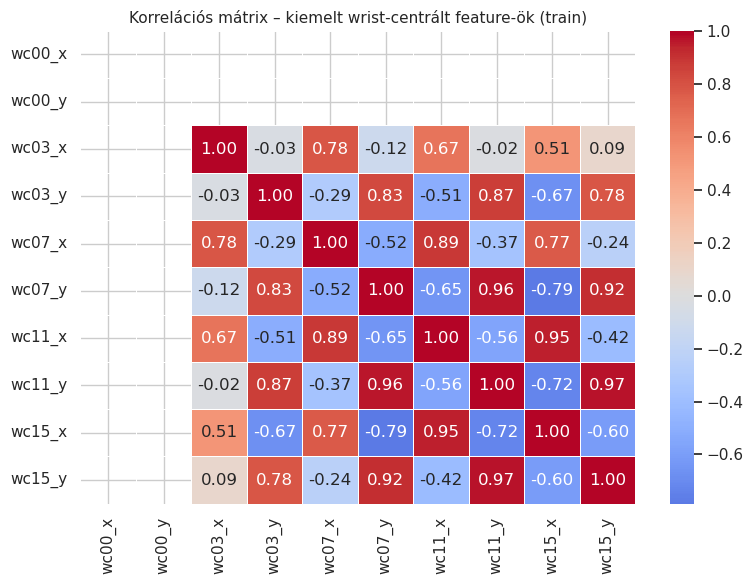

Ábra mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/03_feature_pipeline/feature_correlation.png


In [20]:
# ── 9d. Feature korrelációs heatmap (wrist-centered, mintavételes) ────────────
wc_names = FEATURE_NAMES[GROUP_A_SIZE : GROUP_A_SIZE + GROUP_B_SIZE]

# Csak a kézzel detektált képek
hand_mask = X_train[:, hand_flag_idx].astype(bool)
X_hand    = X_train[hand_mask, wc_start:wc_end]

if X_hand.shape[0] >= 10:
    # Ujjhegyek és csukló feature-ök – 10 kiemelt feature
    key_idx  = [0, 1, 6, 7, 14, 15, 22, 23, 30, 31]   # wrist, index tip, mid tip ...
    key_names = [wc_names[i] for i in key_idx]

    corr = np.corrcoef(X_hand[:, key_idx].T)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                xticklabels=key_names, yticklabels=key_names,
                ax=ax, linewidths=0.4, center=0)
    ax.set_title("Korrelációs mátrix – kiemelt wrist-centrált feature-ök (train)", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_correlation.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Ábra mentve: {OUTPUT_DIR}/feature_correlation.png")
else:
    print("⚠️  Nem elég kézdetekció a korreláció-heatmap-hoz.")

## 10. Normalizálás

**Szabály:** `StandardScaler` csak a **train** adatokon illeszkedik (`fit`).  
A `val` és `test` halmazokra csak `transform`-ot alkalmazunk.  
Ez megakadályozza az adatszivárgást a normalizálási lépésben.

⚠️  A scaler-t elmentjük – az ML notebook és a végső inferencia is ezt tölti be.

In [21]:
import pickle

scaler = StandardScaler()

# Fit CSAK a train adatokon
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler – train adatokon fittelt:")
print(f"  Mean  (első 5 feature): {scaler.mean_[:5].round(4)}")
print(f"  Scale (első 5 feature): {scaler.scale_[:5].round(4)}")
print()
print("Normalizált adatok statisztikái:")
for name, X_s in [("train", X_train_scaled),
                   ("val",   X_val_scaled),
                   ("test",  X_test_scaled)]:
    print(f"  {name:6s}  mean={X_s.mean():.4f}  std={X_s.std():.4f}  "
          f"min={X_s.min():.3f}  max={X_s.max():.3f}")

# Scaler mentése
with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)
print(f"\n✅  Scaler elmentve: {SCALER_PATH}")

# ── CUDA ellenőrzés: konvertálás PyTorch tensorba (CUDA-n ha elérhető) ────────
if CUDA_AVAILABLE:
    Xt_tensor = torch.from_numpy(X_train_scaled).to(DEVICE)
    print(f"\nPyTorch tensor (train, CUDA): {Xt_tensor.shape}  device={Xt_tensor.device}")
    # Felszabadítás – csak demonstráció
    del Xt_tensor
    torch.cuda.empty_cache()
    print("CUDA tensor felszabadítva.")
else:
    print("\n(PyTorch CUDA nem elérhető – tensor demonstráció kihagyva)")

StandardScaler – train adatokon fittelt:
  Mean  (első 5 feature): [0.3601 0.7734 0.     0.3196 0.6806]
  Scale (első 5 feature): [0.1195 0.2408 0.     0.1119 0.2196]

Normalizált adatok statisztikái:
  train   mean=0.0000  std=0.9864  min=-8.680  max=7.842
  val     mean=0.0197  std=1.0415  min=-8.465  max=4.874
  test    mean=0.0103  std=0.9113  min=-4.031  max=3.905

✅  Scaler elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/features/scaler.pkl

PyTorch tensor (train, CUDA): torch.Size([207, 111])  device=cuda:0
CUDA tensor felszabadítva.


## 11. Feature-ök mentése

In [22]:
# ── .npz mentés – nyers és normalizált feature-ök ────────────────────────────
np.savez_compressed(
    FEATURES_PATH,
    # Nyers (nem normalizált)
    X_train=X_train,       y_train=y_train,
    X_val=X_val,           y_val=y_val,
    X_test=X_test,         y_test=y_test,
    # StandardScaler-rel normalizált
    X_train_scaled=X_train_scaled,
    X_val_scaled=X_val_scaled,
    X_test_scaled=X_test_scaled,
    # Osztály-információk
    classes=np.array(CLASSES),
)
print(f"✅  Features.npz elmentve: {FEATURES_PATH}")
print(f"   Méret: {FEATURES_PATH.stat().st_size / 1024:.1f} KB")

# ── Feature nevek mentése (ML notebook referenciájához) ──────────────────────
FEATURE_NAMES_PATH.write_text("\n".join(FEATURE_NAMES))
print(f"✅  Feature nevek: {FEATURE_NAMES_PATH}")

# ── Teljes feature DataFrame mentése CSV-be (inspect + debug célra) ──────────
full_df = pd.DataFrame(
    np.vstack([X_train, X_val, X_test]),
    columns=FEATURE_NAMES,
)
splits = (
    ["train"] * len(X_train) +
    ["val"]   * len(X_val)   +
    ["test"]  * len(X_test)
)
labels_all = np.concatenate([y_train, y_val, y_test])
full_df.insert(0, "split", splits)
full_df.insert(1, "class", [IDX2CLASS[l] for l in labels_all])
full_df.insert(2, "label", labels_all)
csv_path = FEATURES_DIR / "features_full.csv"
full_df.to_csv(csv_path, index=False)
print(f"✅  Teljes feature CSV: {csv_path}")
print(f"   Sorok: {len(full_df)} | Oszlopok: {len(full_df.columns)}")

# ── Betöltési teszt ──────────────────────────────────────────────────────────
data = np.load(FEATURES_PATH)
assert data["X_train"].shape == X_train.shape, "Betöltési hiba!"
print("\n✅  NPZ betöltési teszt sikeres.")
print(f"   X_train shape: {data['X_train'].shape}")
print(f"   y_train shape: {data['y_train'].shape}")
print(f"   Osztályok: {list(data['classes'])}")

✅  Features.npz elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/features/features.npz
   Méret: 222.0 KB
✅  Feature nevek: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/features/feature_names.txt
✅  Teljes feature CSV: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/features/features_full.csv
   Sorok: 297 | Oszlopok: 114

✅  NPZ betöltési teszt sikeres.
   X_train shape: (207, 111)
   y_train shape: (207,)
   Osztályok: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('No hand')]


## 12. Sanity check vizualizáció

Az alábbi vizualizáció 3 képet mutat osztályonként:
- **Zöld téglalap** = detektált fretboard (Hough/kontúr)
- **Piros pontok** = MediaPipe kéz landmark-ok (21 pont)
- **Kék téglalap** = kéz bounding box

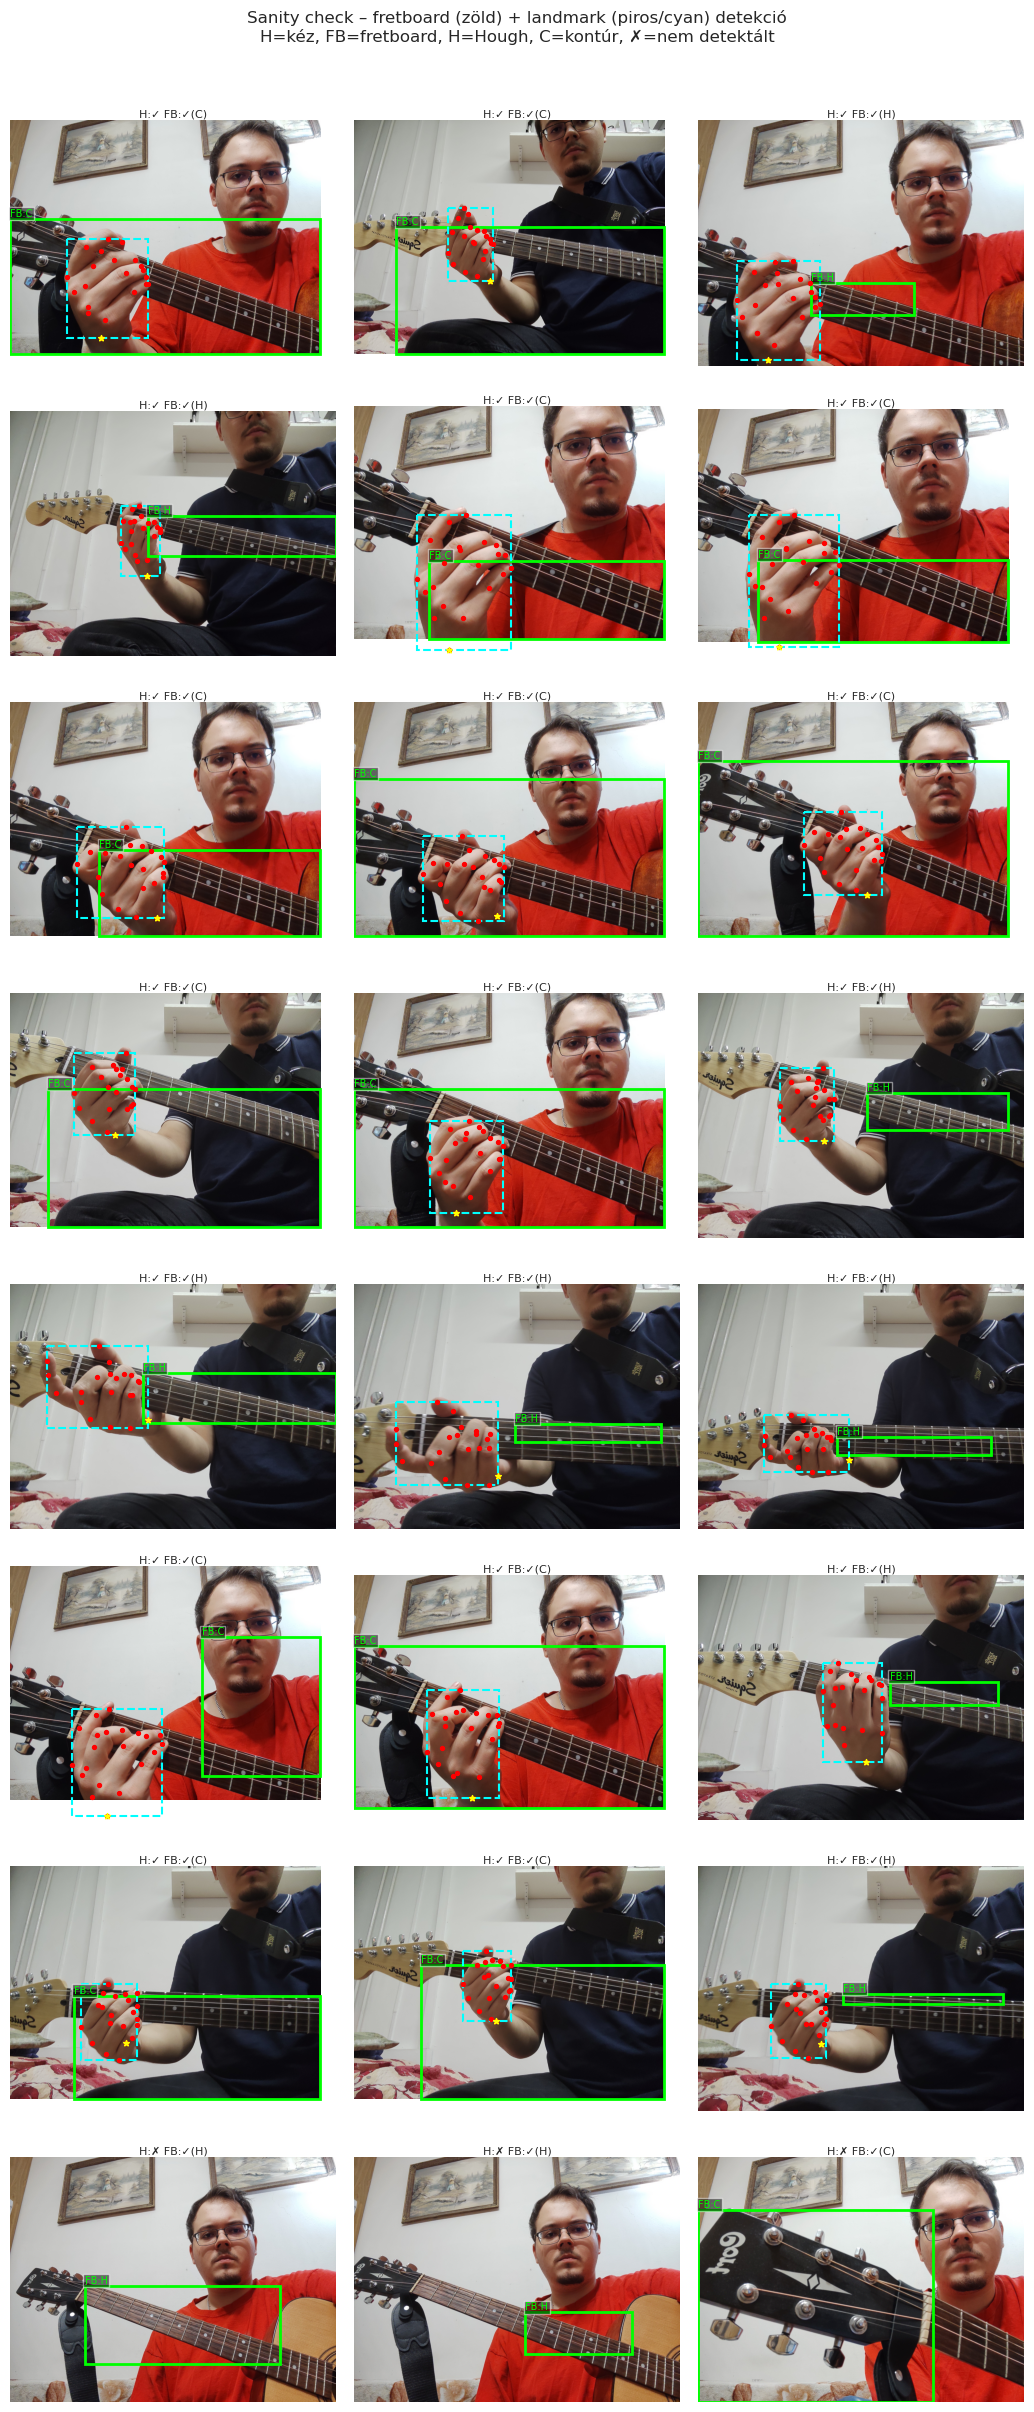

Sanity check ábra mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/03_feature_pipeline/sanity_check_detections.png


In [23]:
def draw_detections(img_path: str, ax) -> dict:
    """
    Kirajzolja a fretboard és landmark detekciót egy képre.
    Returns: {'hand': bool, 'fb': bool, 'fb_method': str}
    """
    # Load image: prefer OpenCV if available, otherwise use PIL fallback
    img_bgr = None
    if CV2_AVAILABLE:
        img_bgr = cv2.imread(img_path)
    else:
        try:
            pil_img = Image.open(img_path).convert("RGB")
            img_rgb = np.array(pil_img)
            # Convert RGB (PIL) to BGR (OpenCV-like) for downstream compatibility
            img_bgr = img_rgb[:, :, ::-1].copy()
        except Exception:
            img_bgr = None

    if img_bgr is None:
        ax.text(0.5, 0.5, "Hiba", ha="center", va="center",
                transform=ax.transAxes, color="red")
        return {"hand": False, "fb": False, "fb_method": "none"}

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_bgr.shape[:2]

    # Fretboard detektálás
    fb = detect_fretboard(img_bgr)
    # Kéz landmark detektálás
    lm = detect_hand_landmarks(img_path, HAND_LANDMARKER)

    ax.imshow(img_rgb)
    ax.axis("off")

    # Fretboard bounding box (zöld)
    if fb is not None:
        rect = patches.Rectangle(
            (fb["x"] * w, fb["y"] * h),
            fb["bw"] * w, fb["bh"] * h,
            linewidth=2, edgecolor="lime", facecolor="none",
            label=f"fretboard ({fb['method']})"
        )
        ax.add_patch(rect)
        ax.text(fb["x"] * w, fb["y"] * h - 4,
                f"FB:{fb['method'][:1].upper()}",
                color="lime", fontsize=7, va="bottom",
                bbox=dict(facecolor="black", alpha=0.5, pad=1))

    # Kéz landmark-ok (piros körök)
    if lm is not None:
        xs = [p[0] * w for p in lm]
        ys = [p[1] * h for p in lm]
        ax.scatter(xs, ys, c="red", s=8, zorder=5)
        # Csukló kiemelt (sárga)
        ax.scatter(xs[0], ys[0], c="yellow", s=18, zorder=6, marker="*")
        # Kéz bounding box (kék)
        hx_min, hx_max = min(xs), max(xs)
        hy_min, hy_max = min(ys), max(ys)
        ax.add_patch(patches.Rectangle(
            (hx_min, hy_min), hx_max - hx_min, hy_max - hy_min,
            linewidth=1.5, edgecolor="cyan", facecolor="none", linestyle="--"
        ))

    return {"hand": lm is not None, "fb": fb is not None,
            "fb_method": fb["method"] if fb else "none"}


# ── Vizualizáció ─────────────────────────────────────────────────────────────
N_PER_CLASS = 3
fig, axes = plt.subplots(
    NUM_CLASSES, N_PER_CLASS,
    figsize=(N_PER_CLASS * 3.5, NUM_CLASSES * 3.0)
)
if NUM_CLASSES == 1:
    axes = axes.reshape(1, -1)

rng = np.random.default_rng(RANDOM_SEED)

for row_idx, cls in enumerate(CLASSES):
    cls_df = train_df[train_df["class"] == cls].reset_index(drop=True)
    picks  = rng.choice(len(cls_df), size=min(N_PER_CLASS, len(cls_df)), replace=False)

    for col_idx in range(N_PER_CLASS):
        ax = axes[row_idx, col_idx]
        if col_idx < len(picks):
            img_row = cls_df.iloc[picks[col_idx]]
            stats   = draw_detections(img_row["path"], ax)

            h_sym = "✓" if stats["hand"] else "✗"
            f_sym = "✓" if stats["fb"]   else "✗"
            title = f"H:{h_sym} FB:{f_sym}({stats['fb_method'][:1].upper()})"
            ax.set_title(title, fontsize=8, pad=2)
        else:
            ax.axis("off")

    axes[row_idx, 0].set_ylabel(cls, fontsize=11, fontweight="bold", rotation=0,
                                 labelpad=35, va="center")

fig.suptitle(
    "Sanity check – fretboard (zöld) + landmark (piros/cyan) detekció\n"
    "H=kéz, FB=fretboard, H=Hough, C=kontúr, ✗=nem detektált",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sanity_check_detections.png",
            dpi=120, bbox_inches="tight")
plt.show()
print(f"Sanity check ábra mentve: {OUTPUT_DIR}/sanity_check_detections.png")

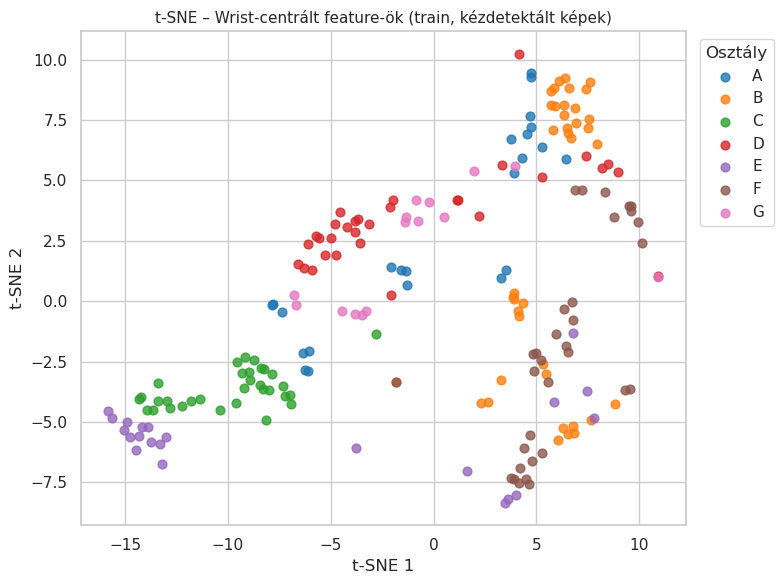

t-SNE ábra mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/03_feature_pipeline/tsne_features.png


In [24]:
# ── Wrist-centrált feature t-SNE vizualizáció (opcionális, de hasznos) ───────
# Csak kézzel detektált képek, Csoport B feature-ök
try:
    from sklearn.manifold import TSNE
    from matplotlib.cm import get_cmap

    hand_mask_tr = X_train[:, hand_flag_idx].astype(bool)
    X_tsne_in    = X_train_scaled[hand_mask_tr, GROUP_A_SIZE:GROUP_A_SIZE + GROUP_B_SIZE]
    y_tsne       = y_train[hand_mask_tr]

    if X_tsne_in.shape[0] >= 20:
        perp = min(30, X_tsne_in.shape[0] - 1)
        tsne = TSNE(n_components=2, perplexity=perp,
                    random_state=RANDOM_SEED, max_iter=1000)
        Z = tsne.fit_transform(X_tsne_in)

        fig, ax = plt.subplots(figsize=(8, 6))
        cmap = get_cmap("tab10")
        for i, cls in enumerate(CLASSES):
            mask_c = y_tsne == CLASS2IDX[cls]
            if mask_c.sum() == 0:
                continue
            ax.scatter(Z[mask_c, 0], Z[mask_c, 1],
                       label=cls, color=cmap(i), s=40, alpha=0.8)
        ax.legend(title="Osztály", bbox_to_anchor=(1.01, 1), loc="upper left")
        ax.set_title("t-SNE – Wrist-centrált feature-ök (train, kézdetektált képek)",
                     fontsize=11)
        ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "tsne_features.png", dpi=120, bbox_inches="tight")
        plt.show()
        print(f"t-SNE ábra mentve: {OUTPUT_DIR}/tsne_features.png")
    else:
        print("⚠️  Nem elég detektált kéz a t-SNE-hez.")

except ImportError:
    print("scikit-learn TSNE nem elérhető (normális).")

## Összefoglaló és következő lépések

### Elkészített fájlok

| Fájl | Tartalom |
|---|---|
| `data/features/features.npz` | X_train/val/test (nyers + scaled), y_train/val/test, classes |
| `data/features/scaler.pkl` | StandardScaler – train-en fittelt |
| `data/features/feature_names.txt` | 111 feature neve sorban |
| `data/features/features_full.csv` | Teljes feature tábla (inspect/debug) |
| `output/03_feature_pipeline/*.png` | Vizualizációk |

### Feature vektor struktúra (111 dim)

| Idx | Csoport | Tartalom |
|---|---|---|
| 0–62 | A | Raw MediaPipe x,y,z – 21 landmark |
| 63–104 | B | Csukló-centrált, skálázott x,y – 21 landmark |
| 105–108 | C | Fretboard bbox (x, y, w, h) |
| 109–110 | D | Flags (hand_detected, fb_detected) |

### Betöltési kód a következő notebookhoz (04a_baseline_ml)

```python
import numpy as np, pickle
from pathlib import Path

data   = np.load("data/features/features.npz")
X_train_scaled = data["X_train_scaled"];  y_train = data["y_train"]
X_val_scaled   = data["X_val_scaled"];    y_val   = data["y_val"]
X_test_scaled  = data["X_test_scaled"];   y_test  = data["y_test"]
CLASSES        = list(data["classes"])

with open("data/features/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
```

### Következő lépések

1. **`04_data_leakage_check.ipynb`** → futtasd le (MD5 + pHash)  
2. **`04a_baseline_ml.ipynb`** → **átírás szükséges**: a fenti betöltési kóddal töltse be  
   a feature vektorokat HOG/ResNet50 helyett  
3. Ha a kézdetekciós ráta alacsony (< 60%): `min_hand_detection_confidence=0.2` csökkentése  
4. Ha a fretboard detekció gyenge: a Hough paraméterek hangolása (`threshold`, `minLineLength`)